In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import scipy as sp

try:
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath}",
    })
except Exception as e:
    print(f"Could not enable LaTeX rendering: {e}\nFalling back to default.")

In [11]:
data = pd.read_parquet(r"C:\Users\rossi\Documents\tesi\apdl\sim\sim_0.006_0.096.parquet")
t = 0.001

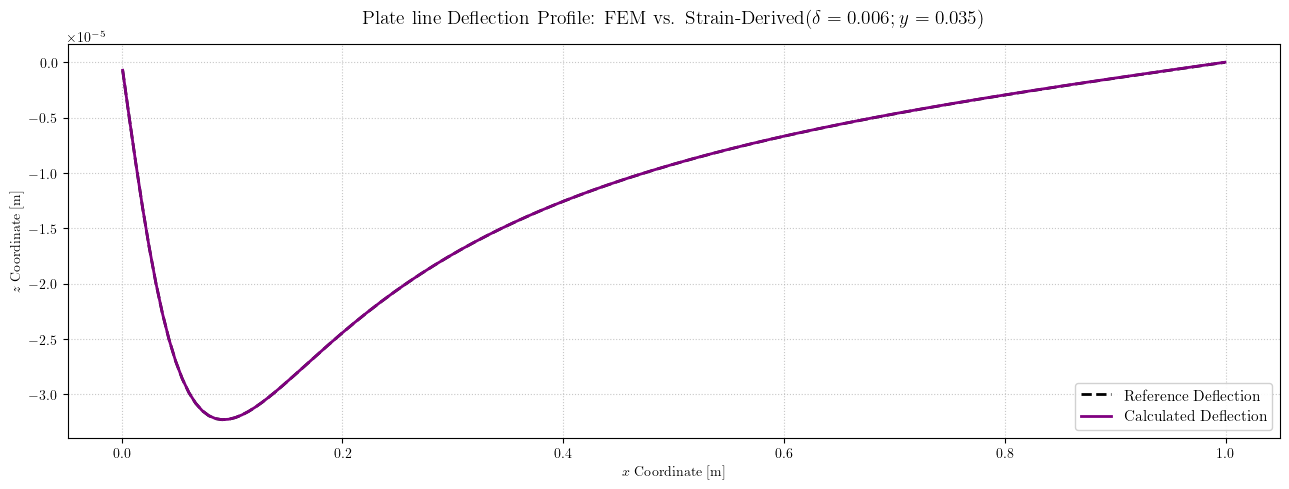

In [12]:
delta = 0.006
Y = 0.035
line_data = data.query(f'abs(((X - 0.001)) % @delta < 1e-6 | abs((X - 0.001) % @delta - @delta) < 1e-6) & Y == @Y | X == 0.999 & Y == @Y')
curvature_line = -line_data['EXX']/t
x_coords = line_data['X'].unique()
y_coords = line_data['Y'].unique()
# z_disp = np.cumsum(np.cumsum(curvature_line.values) * delta) * delta # double integral
z_disp = sp.integrate.cumulative_simpson(sp.integrate.cumulative_simpson(curvature_line.values, x=x_coords, initial=0), x=x_coords, initial=0)
z_disp = z_disp - z_disp[-1] / np.max(x_coords) * x_coords # boudary condition z[a] == 0


fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(line_data['X'].unique(), line_data['Z'], 
         label='Reference Deflection', 
         color='black', 
         linestyle='--', 
         linewidth=2)

# Plot 2: Calculated Data from Strain
ax.plot(line_data['X'].unique(), z_disp, 
         label='Calculated Deflection', 
         color='purple', 
         linewidth=2)

# Titles and Axis Labels
# (Note: Update 'm' to 'mm' or 'in' if your data uses different units)
ax.set_title('Plate line Deflection Profile: FEM vs. Strain-Derived' + f'($\\delta = {delta:.3f}; y = {Y:.3f})$', fontsize=14, pad=15)
ax.set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
ax.set_ylabel(r"$z$ Coordinate $\left[\mathrm{m}\right]$")

# Grid and Legend
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(loc='best', fontsize=11, framealpha=0.9)

# Clean up layout margins and render
plt.tight_layout()
plt.show()

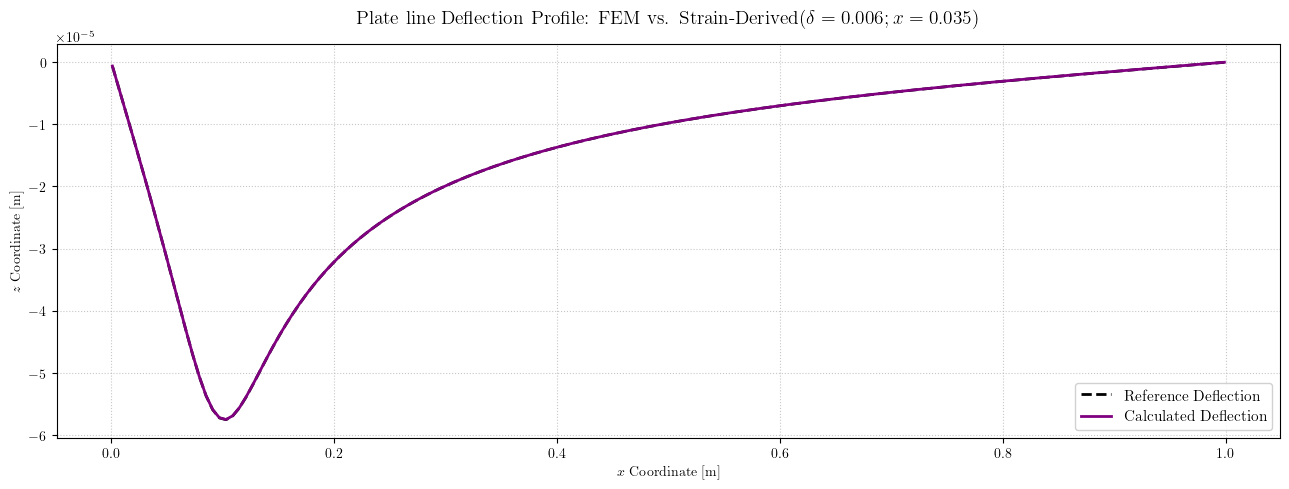

In [13]:
X = 0.035
line_data = data.query(f'(abs(((Y - 0.001)) % @delta < 1e-6 | abs((Y - 0.001) % @delta - @delta) < 1e-6)) & X == @X | Y == 0.999 & X == @X')
curvature_line = -line_data['EYY']/t
x_coords = line_data['X'].unique()
y_coords = line_data['Y'].unique()
z_disp = np.cumsum(np.cumsum(curvature_line.values) * delta) * delta # double integral
z_disp = sp.integrate.cumulative_simpson(sp.integrate.cumulative_simpson(curvature_line.values, x=y_coords, initial=0), x=y_coords, initial=0)
z_disp = z_disp - z_disp[-1] / np.max(y_coords) * y_coords # boudary condition z[a] == 0


fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(line_data['Y'].unique(), line_data['Z'], 
         label='Reference Deflection', 
         color='black', 
         linestyle='--', 
         linewidth=2)

# Plot 2: Calculated Data from Strain
ax.plot(line_data['Y'].unique(), z_disp, 
         label='Calculated Deflection', 
         color='purple', 
         linewidth=2)

# Titles and Axis Labels
# (Note: Update 'm' to 'mm' or 'in' if your data uses different units)
ax.set_title('Plate line Deflection Profile: FEM vs. Strain-Derived' + f'($\\delta = {delta:.3f}; x = {X:.3f})$', fontsize=14, pad=15)
ax.set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
ax.set_ylabel(r"$z$ Coordinate $\left[\mathrm{m}\right]$")

# Grid and Legend
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(loc='best', fontsize=11, framealpha=0.9)

# Clean up layout margins and render
plt.tight_layout()
plt.show()

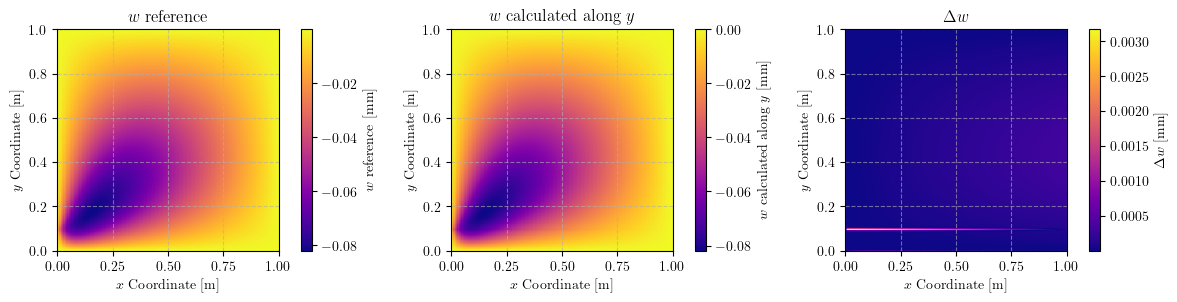

In [14]:
sampled_data = data.query(f'abs(((X - 0.001)) % @delta < 1e-6 | abs((X - 0.001) % @delta - @delta) < 1e-6)')
x_coords = sampled_data['X'].unique()
y_coords = sampled_data['Y'].unique()


z_grid = np.ndarray((len(x_coords), len(y_coords)))

for j, y in enumerate(y_coords):
    line_data = sampled_data.query('abs(Y - @y) < 1e-6')
    curvature_line = -line_data['EXX']/t
    # temp = np.cumsum(np.cumsum(curvature_line.values) * delta) * delta # double integral
    temp = sp.integrate.cumulative_simpson(sp.integrate.cumulative_simpson(curvature_line.values, x=x_coords, initial=0), x=x_coords, initial=0)
    z_grid[:, j] = temp - temp[-1] / np.max(x_coords) * x_coords # boudary condition z[a] == 0

print_df = pd.DataFrame({
    'X': sampled_data['X'],
    'Y': sampled_data['Y'],
    'Z': sampled_data['Z'] * 1e3,
    'Z_calc': z_grid.flatten(order='F') * 1e3,
    'delta' : np.abs(sampled_data['Z'].values - z_grid.flatten(order='F')) * 1e3
})

fig, ax = plt.subplots(1, len(print_df.columns)-2, figsize=(12, 3))

# Define the components to iterate over to avoid repeating code
components = ['Z', 'Z_calc', 'delta']
symbol = [r'$w$ reference', r'$w$ calculated along $y$', r'$\Delta w$']
legend = [r'$\left[\mathrm{mm}\right]$', r'$\left[\mathrm{mm}\right]$', r'$\left[\mathrm{mm}\right]$']

for i, component in enumerate(components):
    # Pivot the dataframe to get a 2D grid of the difference values
    print_pivot = print_df.pivot(index='Y', columns='X', values=component)

    x_coords = print_pivot.columns.to_numpy()
    y_coords = print_pivot.index.to_numpy()
    C = print_pivot.to_numpy()

    X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

    # Plot the pcolormesh specifically on the current axis (ax[i])
    colormesh = ax[i].pcolormesh(X_mesh, Y_mesh, C, cmap="plasma", shading='auto', rasterized=True)

    # Add colorbar to the figure, specifying which axis it belongs to
    cbar = fig.colorbar(colormesh, ax=ax[i], label=f"{symbol[i]} "+ legend[i])
    
    # Use 'set_' methods for axis properties
    ax[i].set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_ylabel(r"$y$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_title(f"{symbol[i]}")
    ax[i].axis("scaled") # Ensures the geometry isn't distorted
    ax[i].grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

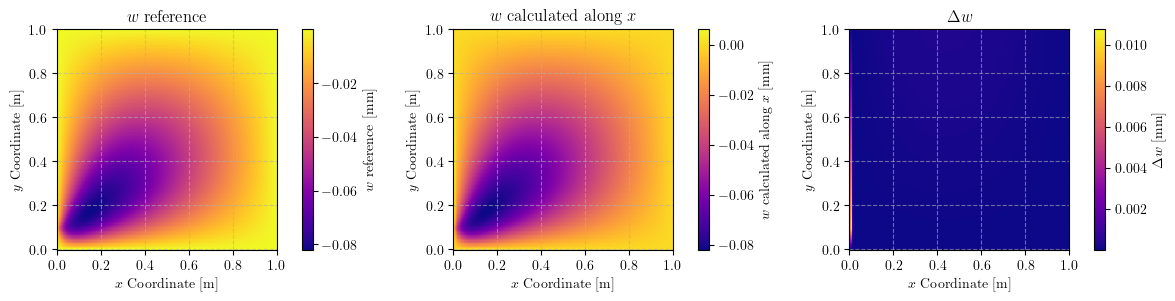

In [15]:
sampled_data = data.query(f'abs(((Y - 0.001)) % @delta < 1e-6 | abs((Y - 0.001) % @delta - @delta) < 1e-6)')
x_coords = sampled_data['X'].unique()
y_coords = sampled_data['Y'].unique()


z_grid = np.ndarray((len(x_coords), len(y_coords)))

for j, x in enumerate(x_coords):
    line_data = sampled_data.query('abs(X - @x) < 1e-6')
    curvature_line = -line_data['EYY']/t
    # temp = np.cumsum(np.cumsum(curvature_line.values) * delta) * delta # double integral
    temp = sp.integrate.cumulative_simpson(sp.integrate.cumulative_simpson(curvature_line.values, x=y_coords, initial=0), x=y_coords, initial=0)
    z_grid[j, :] = temp - temp[-1] / np.max(y_coords) * y_coords # boudary condition z[a] == 0

print_df = pd.DataFrame({
    'X': sampled_data['X'],
    'Y': sampled_data['Y'],
    'Z': sampled_data['Z'] * 1e3,
    'Z_calc': z_grid.flatten(order='F') * 1e3,
    'delta' : np.abs(sampled_data['Z'].values - z_grid.flatten(order='F')) * 1e3
})

fig, ax = plt.subplots(1, len(print_df.columns)-2, figsize=(12, 3))

# Define the components to iterate over to avoid repeating code
components = ['Z', 'Z_calc', 'delta']
symbol = [r'$w$ reference', r'$w$ calculated along $x$', r'$\Delta w$']
legend = [r'$\left[\mathrm{mm}\right]$', r'$\left[\mathrm{mm}\right]$', r'$\left[\mathrm{mm}\right]$']

for i, component in enumerate(components):
    # Pivot the dataframe to get a 2D grid of the difference values
    print_pivot = print_df.pivot(index='Y', columns='X', values=component)

    x_coords = print_pivot.columns.to_numpy()
    y_coords = print_pivot.index.to_numpy()
    C = print_pivot.to_numpy()

    X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

    # Plot the pcolormesh specifically on the current axis (ax[i])
    colormesh = ax[i].pcolormesh(X_mesh, Y_mesh, C, cmap="plasma", shading='auto', rasterized=True)

    # Add colorbar to the figure, specifying which axis it belongs to
    cbar = fig.colorbar(colormesh, ax=ax[i], label=f"{symbol[i]} "+ legend[i])
    
    # Use 'set_' methods for axis properties
    ax[i].set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_ylabel(r"$y$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_title(f"{symbol[i]}")
    ax[i].axis("scaled") # Ensures the geometry isn't distorted
    ax[i].grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

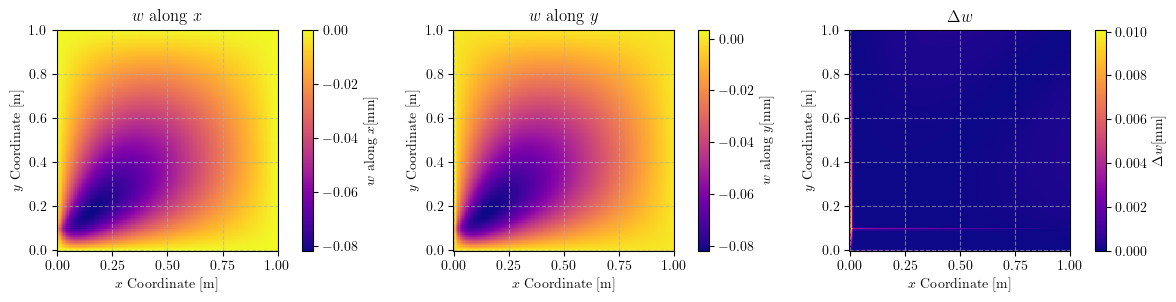

In [16]:
sampled_data = data.query(f'(abs(((Y - 0.001)) % @delta < 1e-6 | abs((Y - 0.001) % @delta - @delta) < 1e-6)) & (abs(((X - 0.001)) % @delta < 1e-6 | abs((X - 0.001) % @delta - @delta) < 1e-6))')
x_coords = sampled_data['X'].unique()
y_coords = sampled_data['Y'].unique()


z_grid_x = np.ndarray((len(x_coords), len(y_coords)))
z_grid_y = np.ndarray((len(x_coords), len(y_coords)))

for j, x in enumerate(x_coords):
    line_data = sampled_data.query('abs(X - @x) < 1e-6')
    curvature_line = -line_data['EYY']/t
    # temp = np.cumsum(np.cumsum(curvature_line.values) * delta) * delta # double integral
    temp = sp.integrate.cumulative_simpson(sp.integrate.cumulative_simpson(curvature_line.values, x=y_coords, initial=0), x=y_coords, initial=0)
    z_grid_y[j, :] = temp - temp[-1] / np.max(y_coords) * y_coords # boudary condition z[a] == 0
    
for j, y in enumerate(y_coords):
    line_data = sampled_data.query('abs(Y - @y) < 1e-6')
    curvature_line = -line_data['EXX']/t
    # temp = np.cumsum(np.cumsum(curvature_line.values) * delta) * delta # double integral
    temp = sp.integrate.cumulative_simpson(sp.integrate.cumulative_simpson(curvature_line.values, x=x_coords, initial=0), x=x_coords, initial=0)
    z_grid_x[:, j] = temp - temp[-1] / np.max(x_coords) * x_coords # boudary condition z[a] == 0

print_df = pd.DataFrame({
    'X': sampled_data['X'],
    'Y': sampled_data['Y'],
    'Z_calc_x': z_grid_x.flatten(order='F') * 1e3,
    'Z_calc_y': z_grid_y.flatten(order='F') * 1e3,
    'delta' : np.abs(z_grid_x.flatten(order='F') - z_grid_y.flatten(order='F')) * 1e3
})

fig, ax = plt.subplots(1, len(print_df.columns)-2, figsize=(12, 3))

# Define the components to iterate over to avoid repeating code
components = ['Z_calc_x', 'Z_calc_y', 'delta']
symbol = [r'$w$ along $x$', r'$w$ along $y$', r'$\Delta w$']
legend = [r'$\left[\mathrm{mm}\right]$', r'$\left[\mathrm{mm}\right]$', r'$\left[\mathrm{mm}\right]$']

for i, component in enumerate(components):
    # Pivot the dataframe to get a 2D grid of the difference values
    print_pivot = print_df.pivot(index='Y', columns='X', values=component)

    x_coords = print_pivot.columns.to_numpy()
    y_coords = print_pivot.index.to_numpy()
    C = print_pivot.to_numpy()

    X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

    # Plot the pcolormesh specifically on the current axis (ax[i])
    colormesh = ax[i].pcolormesh(X_mesh, Y_mesh, C, cmap="plasma", shading='auto', rasterized=True)

    # Add colorbar to the figure, specifying which axis it belongs to
    cbar = fig.colorbar(colormesh, ax=ax[i], label=f"{symbol[i]}"+ legend[i])
    
    # Use 'set_' methods for axis properties
    ax[i].set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_ylabel(r"$y$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_title(f"{symbol[i]}")
    ax[i].axis("scaled") # Ensures the geometry isn't distorted
    ax[i].grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

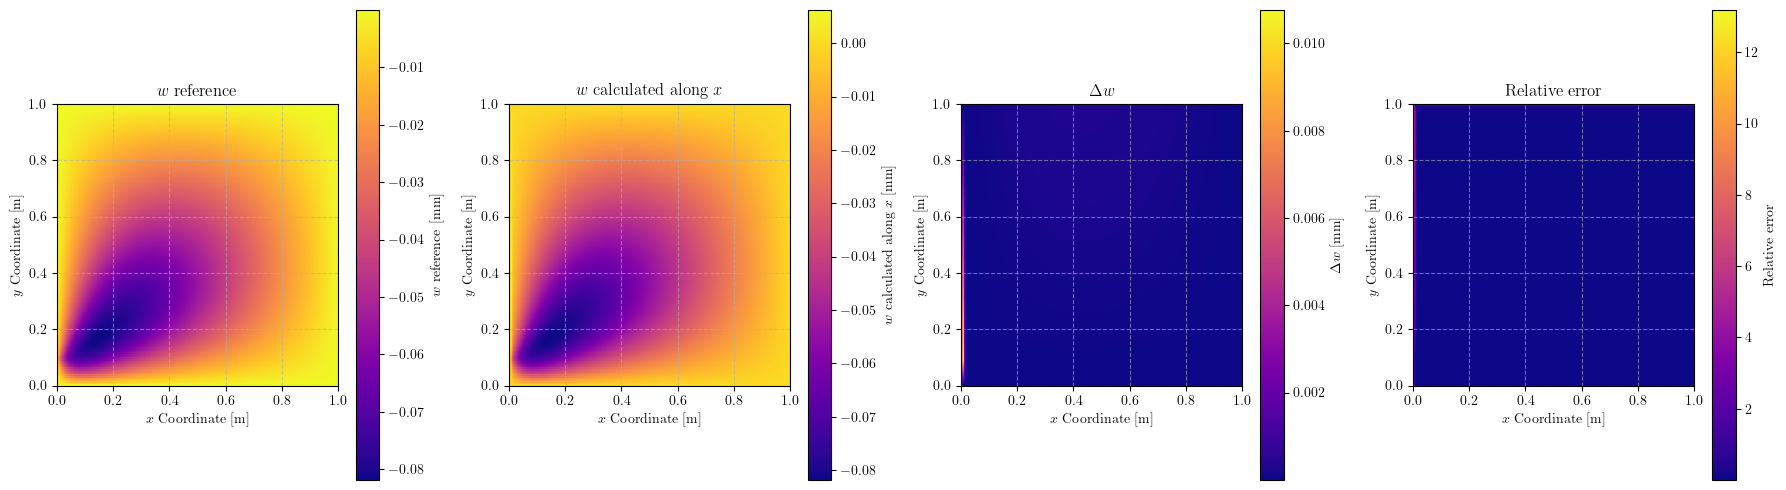

In [19]:
sampled_data = data.query(f'abs(((Y - 0.001)) % @delta < 1e-6 | abs((Y - 0.001) % @delta - @delta) < 1e-6)')
x_coords = sampled_data['X'].unique()
y_coords = sampled_data['Y'].unique()


z_grid = np.ndarray((len(x_coords), len(y_coords)))

for j, x in enumerate(x_coords):
    line_data = sampled_data.query('abs(X - @x) < 1e-6')
    curvature_line = -line_data['EYY']/t
    # temp = np.cumsum(np.cumsum(curvature_line.values) * delta) * delta # double integral
    temp = sp.integrate.cumulative_simpson(sp.integrate.cumulative_simpson(curvature_line.values, x=y_coords, initial=0), x=y_coords, initial=0)
    z_grid[j, :] = temp - temp[-1] / np.max(y_coords) * y_coords # boudary condition z[a] == 0

print_df = pd.DataFrame({
    'X': sampled_data['X'],
    'Y': sampled_data['Y'],
    'Z': sampled_data['Z'] * 1e3,
    'Z_calc': z_grid.flatten(order='F') * 1e3,
    'delta' : np.abs(sampled_data['Z'].values - z_grid.flatten(order='F')) * 1e3,
    'relative' : np.abs((sampled_data['Z'].values - z_grid.flatten(order='F'))/sampled_data['Z'].values),
})

fig, ax = plt.subplots(1, len(print_df.columns)-2, figsize=(18, 5))

# Define the components to iterate over to avoid repeating code
components = ['Z', 'Z_calc', 'delta', 'relative']
symbol = [r'$w$ reference', r'$w$ calculated along $x$', r'$\Delta w$', r'Relative error']
legend = [r'$\left[\mathrm{mm}\right]$', r'$\left[\mathrm{mm}\right]$', r'$\left[\mathrm{mm}\right]$', r'']

for i, component in enumerate(components):
    # Pivot the dataframe to get a 2D grid of the difference values
    print_pivot = print_df.pivot(index='Y', columns='X', values=component)

    x_coords = print_pivot.columns.to_numpy()
    y_coords = print_pivot.index.to_numpy()
    C = print_pivot.to_numpy()

    X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

    # Plot the pcolormesh specifically on the current axis (ax[i])
    colormesh = ax[i].pcolormesh(X_mesh, Y_mesh, C, cmap="plasma", shading='auto', rasterized=True)

    # Add colorbar to the figure, specifying which axis it belongs to
    cbar = fig.colorbar(colormesh, ax=ax[i], label=f"{symbol[i]} "+ legend[i])
    
    # Use 'set_' methods for axis properties
    ax[i].set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_ylabel(r"$y$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_title(f"{symbol[i]}")
    ax[i].axis("scaled") # Ensures the geometry isn't distorted
    ax[i].grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

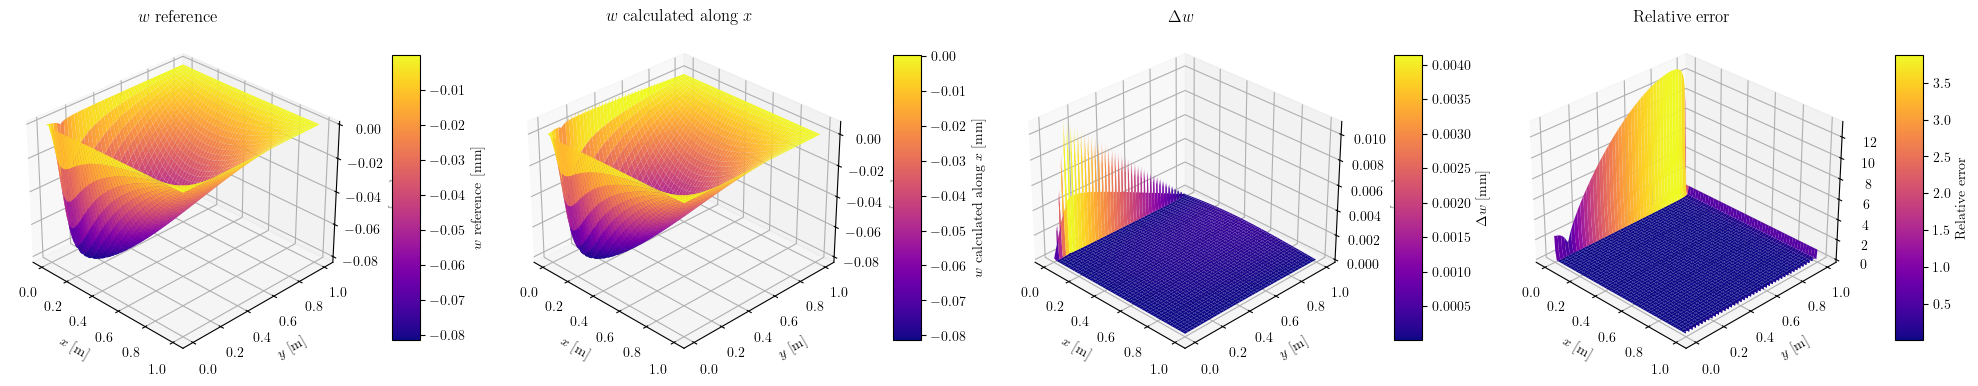

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure you have projection='3d' in the subplots call
fig, ax = plt.subplots(
    1, len(components), 
    figsize=(20, 6), 
    subplot_kw={'projection': '3d'}
)

components = ['Z', 'Z_calc', 'delta', 'relative']
symbol = [r'$w$ reference', r'$w$ calculated along $x$', r'$\Delta w$', r'Relative error']
legend = [r'$\left[\mathrm{mm}\right]$', r'$\left[\mathrm{mm}\right]$', r'$\left[\mathrm{mm}\right]$', r'']

for i, component in enumerate(components):
    # Pivot the dataframe to get a 2D grid
    print_pivot = print_df.pivot(index='Y', columns='X', values=component)

    x_coords = print_pivot.columns.to_numpy()
    y_coords = print_pivot.index.to_numpy()
    C = print_pivot.to_numpy()

    X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

    # Plot the 3D surface
    # 'antialiased=False' often helps with performance and visual clarity in dense meshes
    surf = ax[i].plot_surface(X_mesh, Y_mesh, C, cmap="plasma", edgecolor='none', antialiased=True)

    # Add colorbar
    cbar = fig.colorbar(surf, ax=ax[i], shrink=0.5, aspect=10, pad=0.1)
    cbar.set_label(f"{symbol[i]} {legend[i]}")
    
    # Labeling for 3D axes
    ax[i].set_xlabel(r"$x$ $\left[\mathrm{m}\right]$")
    ax[i].set_ylabel(r"$y$ $\left[\mathrm{m}\right]$")
    ax[i].set_zlabel(legend[i])
    ax[i].set_title(f"{symbol[i]}")
    
    # Improve the viewing angle (optional)
    ax[i].view_init(elev=30, azim=-45)

plt.tight_layout()
plt.show()